# Bloom Filter

This notebook demonstrates the Bloom filter implementation and covers the analysis:
- Basic usage demo
- Time and space complexity discussion
- False positive rate as a function of inserted elements
- Compression ratio analysis

In [18]:
from bloom_filter import BloomFilter
import matplotlib.pyplot as plt
import random
import string

## 1. Basic Demo

We create a Bloom filter, insert some words, and test membership.

In [19]:
inserted = [
    "apple", "banana", "cherry", "date", "elderberry",
    "fig", "grape", "honeydew", "kiwi", "lemon"
]

not_inserted = [
    "mango", "nectarine", "orange", "papaya", "quince",
    "raspberry", "strawberry", "tangerine", "watermelon", "zucchini"
]

bf = BloomFilter(expected_items=100, false_positive_rate=0.01)

for word in inserted:
    bf.insert(word)

print(bf)
print()

# all of these should return True
# no false negatives allowed
print("words we inserted:")
for word in inserted:
    print(f"  {word}: {bf.search(word)}")

print()

# these should mostly be False
# we might see a false positives
print("words we did NOT insert:")
for word in not_inserted:
    result = bf.search(word)
    note = "  <-- false positive" if result else ""
    print(f"  {word}: {result}{note}")


words we inserted:
  apple: True
  banana: True
  cherry: True
  date: True
  elderberry: True
  fig: True
  grape: True
  honeydew: True
  kiwi: True
  lemon: True

words we did NOT insert:
  mango: False
  nectarine: False
  orange: False
  papaya: False
  quince: False
  raspberry: False
  strawberry: False
  tangerine: False
  watermelon: False
  zucchini: False


## 2. Time and Space Complexity

**Time complexity**

Both `insert` and `search` compute `k` hash indices and then do `k` bit array lookups or assignments. Since `k` is a constant determined at construction time (based on capacity and fp_rate), both operations run in **O(k)** time, effectively O(1) since k doesn't grow with the number of inserted elements.

**Space complexity**

The filter uses a bit array of size `m`, which is determined by:

$$m = \lceil -n \cdot \ln(p) \;/\; (\ln 2)^2 \rceil$$

So space is **O(n)**, linear in the expected number of elements.

In [20]:
print(f"{'expected items':>12}  {'bit array size':>16}  {'num hashes':>12}  {'size (KB)':>10}")
print("-" * 58)

for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    tmp = BloomFilter(expected_items=n, false_positive_rate=0.01)
    print(f"{n:>12,}  {tmp.size:>16,}  {tmp.number_of_hashes:>12}  {tmp.size / 8 / 1024:>9.1f}")

expected items    bit array size    num hashes   size (KB)
----------------------------------------------------------
         100               959             7        0.1
       1,000             9,586             7        1.2
      10,000            95,851             7       11.7
     100,000           958,506             7      117.0
   1,000,000         9,585,059             7     1170.1


## 3. False Positive Rate vs Number of Inserted Elements

We insert words one by one and track how the false positive rate changes. We also go beyond the designed capacity to see what happens.

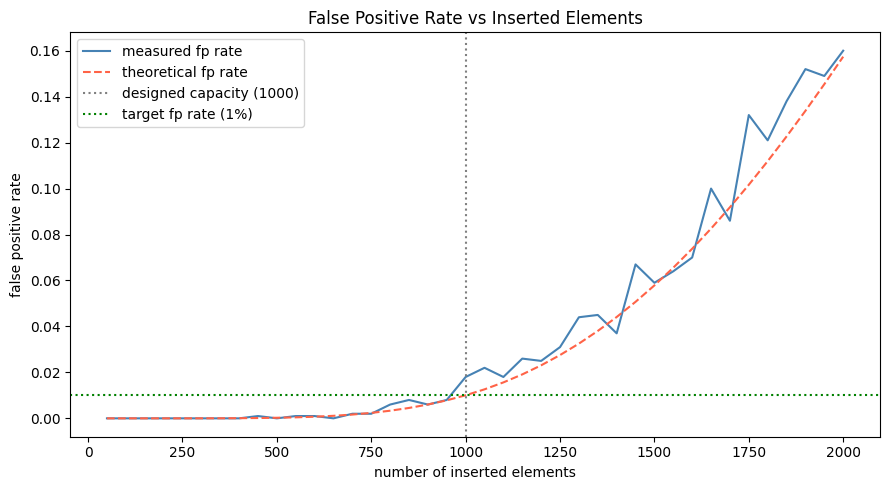

In [21]:
def random_word(length=8):
    return ''.join(random.choices(string.ascii_lowercase, k=length))

def measure_fp_rate(bf, n_tests=1000):
    # search for random words that were never inserted and count how many return True
    hits = sum(1 for _ in range(n_tests) if bf.search(random_word()))
    return hits / n_tests

capacity = 1000
bf = BloomFilter(expected_items=capacity, false_positive_rate=0.01)

counts = []
measured = []
theoretical = []

# insert up to 2 times the capacity to see what happens when we go over the limit
for _ in range(capacity * 2):
    bf.insert(random_word(length=10))

    if bf.count % 50 == 0:
        counts.append(bf.count)
        measured.append(measure_fp_rate(bf))
        theoretical.append(bf.current_fp_rate)

plt.figure(figsize=(9, 5))
plt.plot(counts, measured, label="measured fp rate", color="steelblue")
plt.plot(counts, theoretical, linestyle="--", label="theoretical fp rate", color="tomato")
plt.axvline(x=capacity, color="gray", linestyle=":", label=f"designed capacity ({capacity})")
plt.axhline(y=0.01, color="green", linestyle=":", label="target fp rate (1%)")
plt.xlabel("number of inserted elements")
plt.ylabel("false positive rate")
plt.title("False Positive Rate vs Inserted Elements")
plt.legend()
plt.tight_layout()
plt.savefig("fp_rate_plot.png", dpi=150)
plt.show()

## 4. Compression Ratio Analysis

We check how the compression ratio of the Bloom filter changes as a function of:
- the expected number of elements (capacity)
- the desired false positive rate

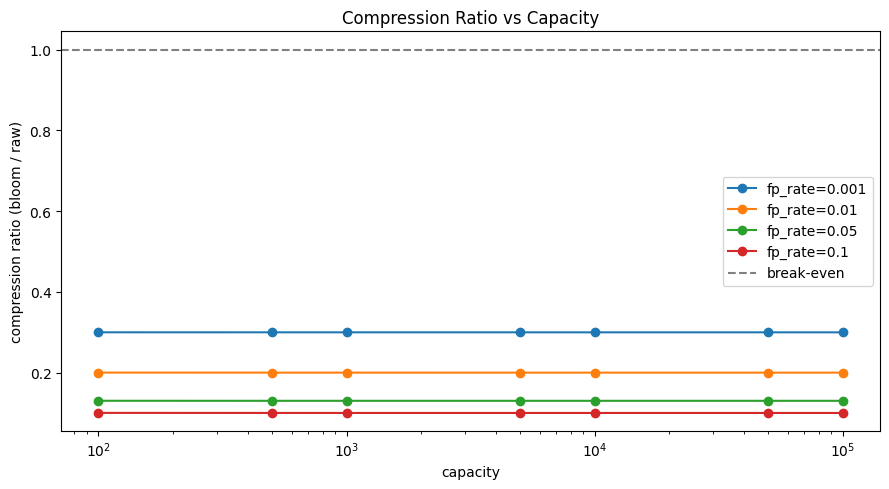

In [22]:
capacities = [100, 500, 1000, 5000, 10000, 50000, 100000]
fp_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(9, 5))

for fp in fp_rates:
    ratios = []
    for n in capacities:
        tmp = BloomFilter(expected_items=n, false_positive_rate=fp)
        for _ in range(n):
            tmp.insert(random_word())
        ratios.append(tmp.compression_ratio)
    plt.plot(capacities, ratios, marker="o", label=f"fp_rate={fp}")

plt.axhline(y=1.0, color="gray", linestyle="--", label="break-even")
plt.xlabel("capacity")
plt.ylabel("compression ratio (bloom / raw)")
plt.title("Compression Ratio vs Capacity")
plt.xscale("log")
plt.legend()
plt.tight_layout()
plt.savefig("compression_ratio_plot.png", dpi=150)
plt.show()